# Sentiment Analysis — Model Comparison

- This notebook compares the final sentiment-classification results obtained using different text representation techniques and BERT.

- The models were developed and evaluated separately in the previous notebooks using the same fixed **72% / 8% / 20% train-validation-test split**.

- This notebook focuses only on comparing the final test-set results and drawing conclusions from the experiments.

### Imports

In [1]:
import pandas as pd

### Load all final results

In [2]:
bow_tfidf_results = pd.read_csv(
    "D:/NLP-Projects/sentiment-analysis-imdb/results/bow_tfidf_results.csv"
)

embedding_results = pd.read_csv(
    "D:/NLP-Projects/sentiment-analysis-imdb/results/word_embeddings_results.csv"
)

bert_results = pd.read_csv(
    "D:/NLP-Projects/sentiment-analysis-imdb/results/bert_results.csv"
)

In [3]:
print("BoW / TF-IDF:")
display(bow_tfidf_results)

print("\nWord Embeddings:")
display(embedding_results)

print("\nBERT:")
display(bert_results)

BoW / TF-IDF:


,representation,configuration,accuracy,precision,recall,f1,classifier
0,BoW,"ngram_range=(1,2), min_df=2",0.902793,0.898986,0.908379,0.903658,LogisticRegression
1,TF-IDF,"ngram_range=(1,2), min_df=2",0.895936,0.885630,0.910187,0.897741,LogisticRegression



Word Embeddings:


,representation,configuration,classifier,accuracy,precision,recall,f1
0,Word2Vec,skipgram_200,LogisticRegression,0.881920,0.879084,0.886679,0.882865
1,FastText,skipgram_200,LogisticRegression,0.881920,0.879689,0.885875,0.882771
2,Doc2Vec,pv_dbow_100,LogisticRegression,0.893315,0.898191,0.888085,0.893110



BERT:


,representation,configuration,classifier,accuracy,precision,recall,f1
0,BERT,"Fine-tuned BERT, max_length=256, epochs=2",BERT classification head,0.924876,0.924559,0.925859,0.925208


### Combine results

In [5]:
all_results = pd.concat(
    [
        bow_tfidf_results,
        embedding_results,
        bert_results
    ],
    ignore_index=True
)


In [6]:
all_results = all_results.sort_values(
    "f1",
    ascending=False
).reset_index(drop=True)

all_results

,representation,configuration,accuracy,precision,recall,f1,classifier
0,BERT,"Fine-tuned BERT, max_length=256, epochs=2",0.924876,0.924559,0.925859,0.925208,BERT classification head
1,BoW,"ngram_range=(1,2), min_df=2",0.902793,0.898986,0.908379,0.903658,LogisticRegression
2,TF-IDF,"ngram_range=(1,2), min_df=2",0.895936,0.885630,0.910187,0.897741,LogisticRegression
3,Doc2Vec,pv_dbow_100,0.893315,0.898191,0.888085,0.893110,LogisticRegression
4,Word2Vec,skipgram_200,0.881920,0.879084,0.886679,0.882865,LogisticRegression
5,FastText,skipgram_200,0.881920,0.879689,0.885875,0.882771,LogisticRegression


In [8]:
# Display only the important columns
comparison_table = all_results[
    [
        "representation",
        "configuration",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
]

comparison_table

,representation,configuration,accuracy,precision,recall,f1
0,BERT,"Fine-tuned BERT, max_length=256, epochs=2",0.924876,0.924559,0.925859,0.925208
1,BoW,"ngram_range=(1,2), min_df=2",0.902793,0.898986,0.908379,0.903658
2,TF-IDF,"ngram_range=(1,2), min_df=2",0.895936,0.885630,0.910187,0.897741
3,Doc2Vec,pv_dbow_100,0.893315,0.898191,0.888085,0.893110
4,Word2Vec,skipgram_200,0.881920,0.879084,0.886679,0.882865
5,FastText,skipgram_200,0.881920,0.879689,0.885875,0.882771


## Overall Comparison — Observations

- **BERT achieved the best overall performance**, with a test accuracy of **92.49%** and an F1 score of **92.52%**.
- Among the classical text-representation approaches, **BoW performed best**, achieving **90.28% accuracy** and an F1 score of **90.37%**.
- **TF-IDF** was the second-best classical approach, with **89.59% accuracy** and an F1 score of **89.77%**.
- Among the embedding-based approaches, **Doc2Vec performed best**, achieving **89.33% accuracy** and an F1 score of **89.31%**.
- Word2Vec and FastText produced very similar results, with F1 scores of **88.29%** and **88.28%**, respectively.
- Overall, the results show a clear performance advantage for the fine-tuned BERT model over the classical and embedding-based approaches tested in this project.
- One notable result was that the **BoW and TF-IDF approaches outperformed Doc2Vec** on the test set. This suggests that for this IMDb sentiment-classification task, preserving explicit word and phrase information was more effective than compressing each review into a dense document-level embedding. The use of **unigrams and bigrams** in BoW likely helped the classifier capture sentiment-bearing words and phrases directly.



### Validation vs Test — Observations

- The relative ranking of the approaches was **largely consistent between validation and test results**.
- **BoW remained the strongest classical approach**, while **Doc2Vec remained the strongest embedding-based approach**.
- The best configurations selected during validation also performed well on the unseen test set, indicating that the selected configurations **generalized reasonably well**.
- The final test results therefore support the conclusions drawn from the validation experiments, with **BERT remaining the best-performing approach overall**.

### Identify the best model

In [9]:
best_model = all_results.loc[
    all_results["f1"].idxmax()
]

best_model

representation                                         BERT
configuration     Fine-tuned BERT, max_length=256, epochs=2
accuracy                                           0.924876
precision                                          0.924559
recall                                             0.925859
f1                                                 0.925208
classifier                         BERT classification head
Name: 0, dtype: object

### Visualization

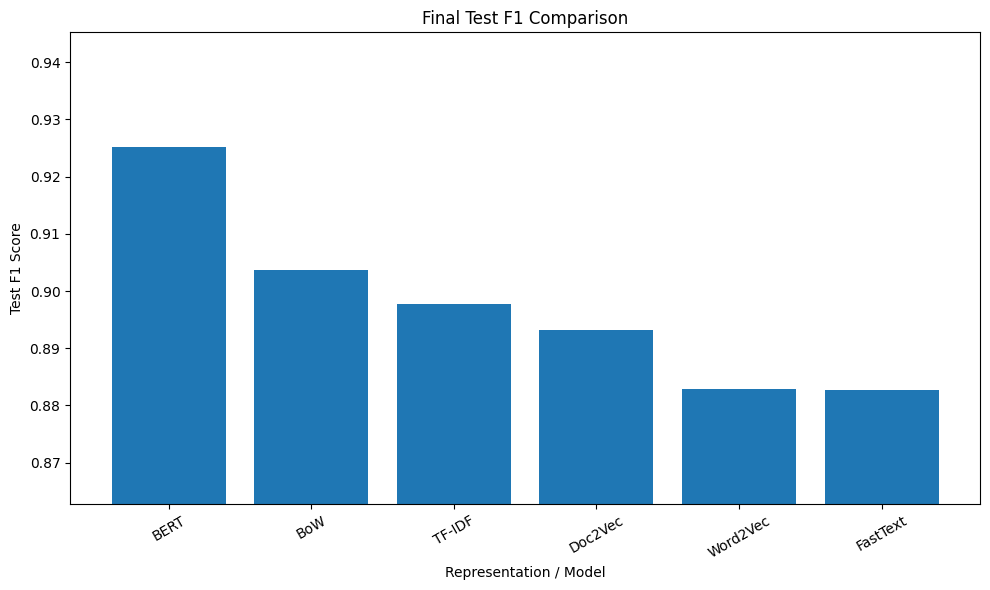

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    comparison_table["representation"],
    comparison_table["f1"]
)

plt.xlabel("Representation / Model")
plt.ylabel("Test F1 Score")
plt.title("Final Test F1 Comparison")

plt.ylim(
    comparison_table["f1"].min() - 0.02,
    comparison_table["f1"].max() + 0.02
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Final Conclusion

This project compared six approaches to IMDb sentiment classification: **BoW, TF-IDF, Word2Vec, FastText, Doc2Vec, and BERT**.

The results show that **BERT achieved the strongest overall performance**, with a test F1 score of **92.52%**, outperforming the best classical and embedding-based approaches.

Among the non-BERT approaches, **BoW achieved the highest test F1 score (90.37%)**, followed by TF-IDF (89.77%) and Doc2Vec (89.31%).

The comparison demonstrates that different text representations can produce substantially different results even when the same sentiment-classification task and downstream classification approach are used. The fine-tuned BERT model benefited from its contextual representation of the review text and provided the strongest performance in this experiment.